## Dataset Exploration

In [2]:
from pathlib import Path

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


test:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 49 images
  autobus: 49 images
  kamyun: 36 images
  kamyunet: 64 images
  minibus: 48 images
  savari: 51 images
  taxi: 50 images
  vanet: 50 images
Total images: 397

train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 348 images
  autobus: 466 images
  kamyun: 335 images
  kamyunet: 595 images
  minibus: 399 images
  savari: 502 images
  taxi: 480 images
  vanet: 746 images
Total images: 3871


In [4]:
from pathlib import Path

import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Locate the raw dataset
# ---------------------------------------------------------

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}


# ---------------------------------------------------------
# 2. Inspect every image in every class of every split
# ---------------------------------------------------------

records = []

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):

        for file_path in sorted(class_dir.rglob("*")):

            # Ignore files that are not recognized as images
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in image_extensions:
                continue

            # Default values in case the image cannot be read
            width = None
            height = None
            dpi_x = None
            dpi_y = None
            image_format = None
            mode = None
            readable = False
            aspect_ratio = None
            error = None

            try:
                # Open the image
                with Image.open(file_path) as img:

                    # Basic image information
                    width, height = img.size
                    image_format = img.format
                    mode = img.mode

                    # DPI information
                    dpi = img.info.get("dpi")

                    if dpi is not None:
                        dpi_x, dpi_y = dpi

                    # Aspect ratio
                    if height != 0:
                        aspect_ratio = width / height

                    # Verify that the image data can actually be read
                    img.verify()

                    readable = True

            except Exception as e:
                error = str(e)

            # Store everything in one record
            records.append({
                "split": split_dir.name,
                "class": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path),
                "width": width,
                "height": height,
                "dpi_x": dpi_x,
                "dpi_y": dpi_y,
                "format": image_format,
                "mode": mode,
                "readable": readable,
                "aspect_ratio": aspect_ratio,
                "error": error,
            })


# ---------------------------------------------------------
# 3. Create one master DataFrame
# ---------------------------------------------------------

image_metadata = pd.DataFrame(records)


# ---------------------------------------------------------
# 4. Display basic information
# ---------------------------------------------------------

print(f"Total images inspected: {len(image_metadata)}")

print(
    f"Unreadable images: "
    f"{(~image_metadata['readable']).sum()}"
)

Total images inspected: 4268
Unreadable images: 0


In [ ]:
from pathlib import Path

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


test:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 49 images
  autobus: 49 images
  kamyun: 36 images
  kamyunet: 64 images
  minibus: 48 images
  savari: 51 images
  taxi: 50 images
  vanet: 50 images
Total images: 397

train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 348 images
  autobus: 466 images
  kamyun: 335 images
  kamyunet: 595 images
  minibus: 399 images
  savari: 502 images
  taxi: 480 images
  vanet: 746 images
Total images: 3871


In [ ]:
from pathlib import Path

import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Locate the raw dataset
# ---------------------------------------------------------

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}


# ---------------------------------------------------------
# 2. Inspect every image in every class of every split
# ---------------------------------------------------------

records = []

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):

        for file_path in sorted(class_dir.rglob("*")):

            # Ignore files that are not recognized as images
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in image_extensions:
                continue

            # Default values in case the image cannot be read
            width = None
            height = None
            dpi_x = None
            dpi_y = None
            image_format = None
            mode = None
            readable = False
            aspect_ratio = None
            error = None

            try:
                # Open the image
                with Image.open(file_path) as img:

                    # Basic image information
                    width, height = img.size
                    image_format = img.format
                    mode = img.mode

                    # DPI information
                    dpi = img.info.get("dpi")

                    if dpi is not None:
                        dpi_x, dpi_y = dpi

                    # Aspect ratio
                    if height != 0:
                        aspect_ratio = width / height

                    # Verify that the image data can actually be read
                    img.verify()

                    readable = True

            except Exception as e:
                error = str(e)

            # Store everything in one record
            records.append({
                "split": split_dir.name,
                "class": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path),
                "width": width,
                "height": height,
                "dpi_x": dpi_x,
                "dpi_y": dpi_y,
                "format": image_format,
                "mode": mode,
                "readable": readable,
                "aspect_ratio": aspect_ratio,
                "error": error,
            })


# ---------------------------------------------------------
# 3. Create one master DataFrame
# ---------------------------------------------------------

image_metadata = pd.DataFrame(records)


# ---------------------------------------------------------
# 4. Display basic information
# ---------------------------------------------------------

print(f"Total images inspected: {len(image_metadata)}")

print(
    f"Unreadable images: "
    f"{(~image_metadata['readable']).sum()}"
)

Total images inspected: 4268
Unreadable images: 0


# finding duplicate images dataset

In [5]:
from IPython.display import HTML, display
from vehicle_classifier import duplicate_detection as dd

THRESHOLD = 0.9

hashed = dd.compute_phashes(dataset_dir='../dataset/Combined Dataset',hash_method = "phash" )
report = dd.build_duplicate_report(hashed, similarity_threshold=THRESHOLD)

print('='*20)
print('--- all similar pairs ---')
display(HTML(dd.table_to_html(report)))

# dd.save_duplicate_report(report)
# dd.save_label_corrections(report)

# dd.compare_images(
#     r"dataset\raw\train\autobus\216664450.jpg",
#     r"dataset\raw\train\autobus\216802875.jpg",
#     hash_method="phash",   # "ahash" | "phash" | "dhash" | "whash"
# )

Scanned: ..\dataset\Combined Dataset  |  hash method: phash (16x16)  |  Hashed images: 4268  |  Failed to hash: 0
Compared 9105778 pairs  |  listed: similarity >= 0.90 (Hamming distance <= 25 of 256)  |  similar pairs found: 0
--- all similar pairs ---


similarity,cluster_num,same_class,class_a,class_b,same_split,split_a,split_b,filename_a,path_a,filename_b,path_b,auto_decision


## finding too much similarities for preventing dataleakage

Scanned: ..\dataset\Combined Dataset  |  hash method: phash (16x16)  |  Hashed images: 4268  |  Failed to hash: 0
Compared 9105778 pairs  |  listed: similarity >= 0.75 (Hamming distance <= 64 of 256)  |  similar pairs found: 745
Clusters (size: count) -> none
Rows needing manual review: 745
--- all similar pairs ---


similarity,cluster_num,same_class,class_a,class_b,same_split,split_a,split_b,filename_a,path_a,filename_b,path_b,auto_decision
0.898,,True,minibus,minibus,True,train,train,206185314.jpg,..\dataset\Combined Dataset\train\minibus\206185314.jpg,206187052.jpg,..\dataset\Combined Dataset\train\minibus\206187052.jpg,needs review
0.891,,True,autobus,autobus,True,train,train,215770203.jpg,..\dataset\Combined Dataset\train\autobus\215770203.jpg,216664450.jpg,..\dataset\Combined Dataset\train\autobus\216664450.jpg,needs review
0.891,,True,minibus,minibus,True,train,train,218252019.jpg,..\dataset\Combined Dataset\train\minibus\218252019.jpg,218982546.jpg,..\dataset\Combined Dataset\train\minibus\218982546.jpg,needs review
0.883,,True,minibus,minibus,True,train,train,215607636.jpg,..\dataset\Combined Dataset\train\minibus\215607636.jpg,215772703.jpg,..\dataset\Combined Dataset\train\minibus\215772703.jpg,needs review
0.883,,True,minibus,minibus,True,train,train,215607636.jpg,..\dataset\Combined Dataset\train\minibus\215607636.jpg,218252019.jpg,..\dataset\Combined Dataset\train\minibus\218252019.jpg,needs review
0.883,,True,minibus,minibus,True,train,train,215607636.jpg,..\dataset\Combined Dataset\train\minibus\215607636.jpg,218596879.jpg,..\dataset\Combined Dataset\train\minibus\218596879.jpg,needs review
0.875,,True,savari,savari,False,test,train,213155633.jpg,..\dataset\Combined Dataset\test\savari\213155633.jpg,212245343.jpg,..\dataset\Combined Dataset\train\savari\212245343.jpg,needs review
0.875,,True,vanet,vanet,False,test,train,217192410.jpg,..\dataset\Combined Dataset\test\vanet\217192410.jpg,217018686.jpg,..\dataset\Combined Dataset\train\vanet\217018686.jpg,needs review
0.875,,True,vanet,vanet,True,train,train,213453392.jpg,..\dataset\Combined Dataset\train\vanet\213453392.jpg,217554061.jpg,..\dataset\Combined Dataset\train\vanet\217554061.jpg,needs review
0.867,,True,minibus,minibus,False,test,train,216249951.jpg,..\dataset\Combined Dataset\test\minibus\216249951.jpg,216430711.jpg,..\dataset\Combined Dataset\train\minibus\216430711.jpg,needs review

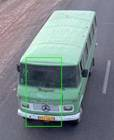
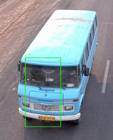
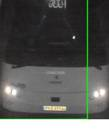
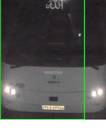
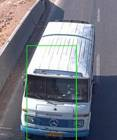
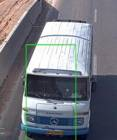
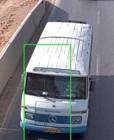
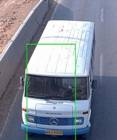
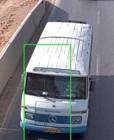
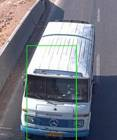
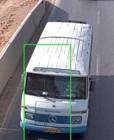
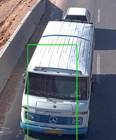
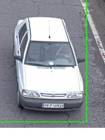
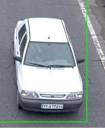
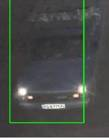
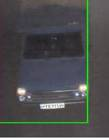
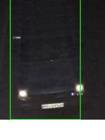
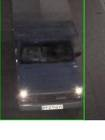
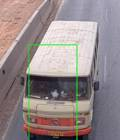
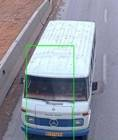
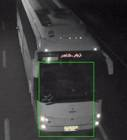
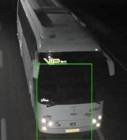
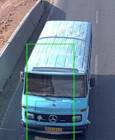
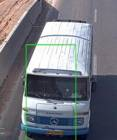
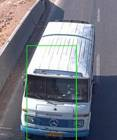
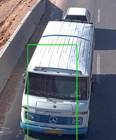
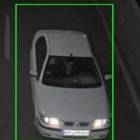
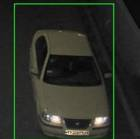
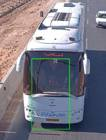
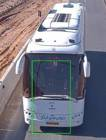
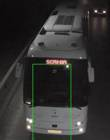
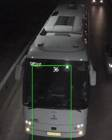
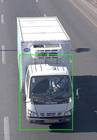
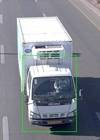
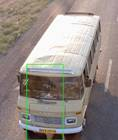
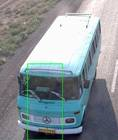
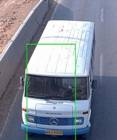
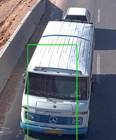
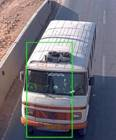
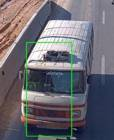
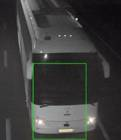
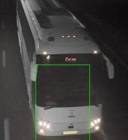
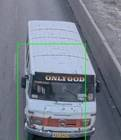
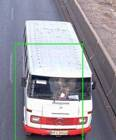
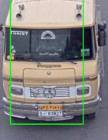
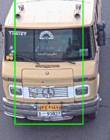
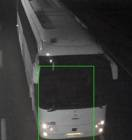
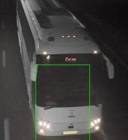
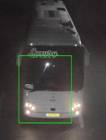
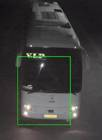
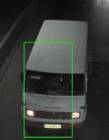
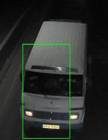
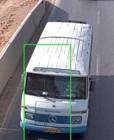
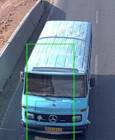
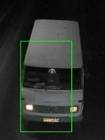
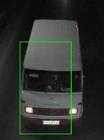
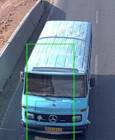
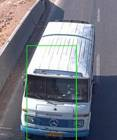
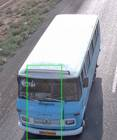
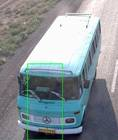
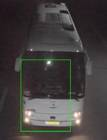
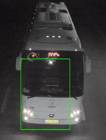
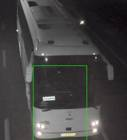
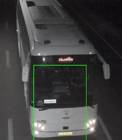
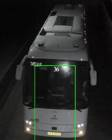
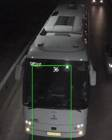
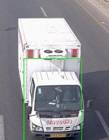
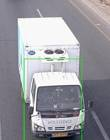
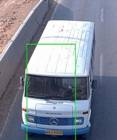
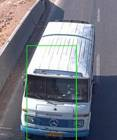
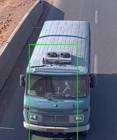
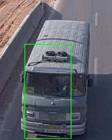
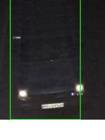
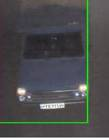
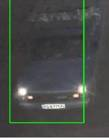
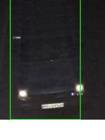
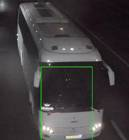
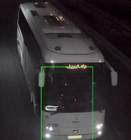
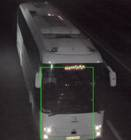
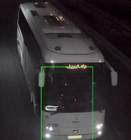
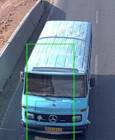
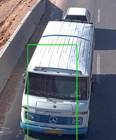
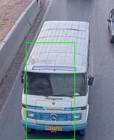
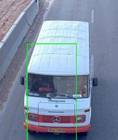
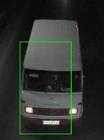
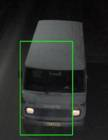
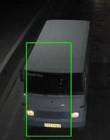
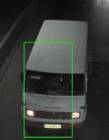
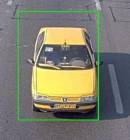
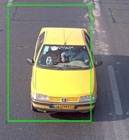
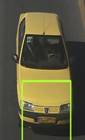
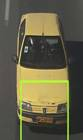
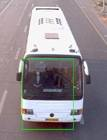
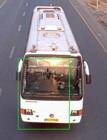
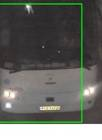
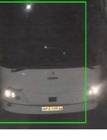
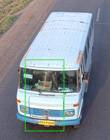
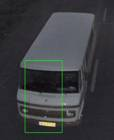
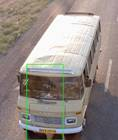
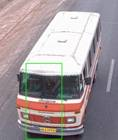
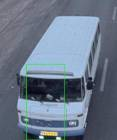
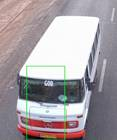
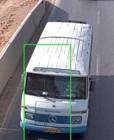
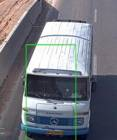
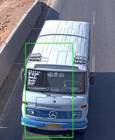
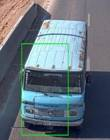
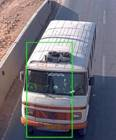
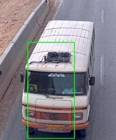
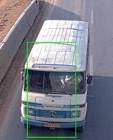
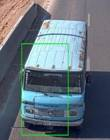
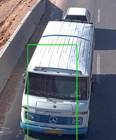
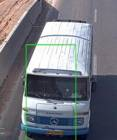
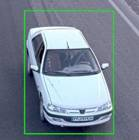
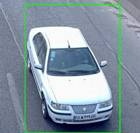
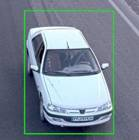
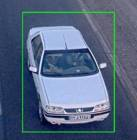
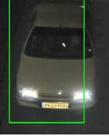
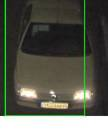
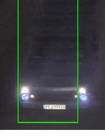
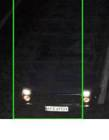
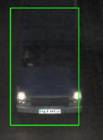
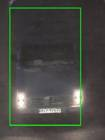
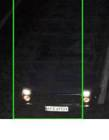
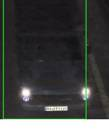
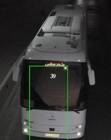
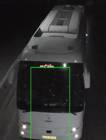
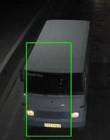
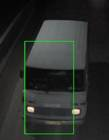
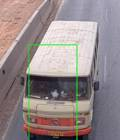
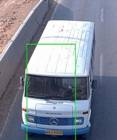
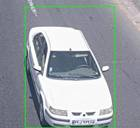
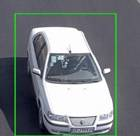
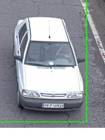
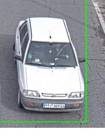
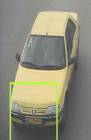
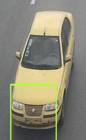
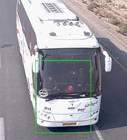
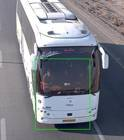
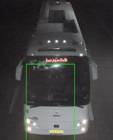
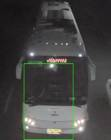
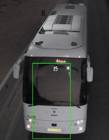
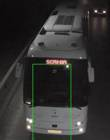
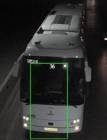
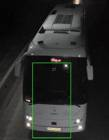
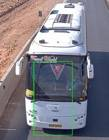
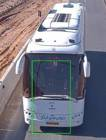
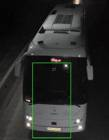
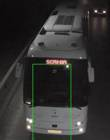
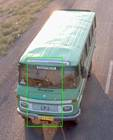
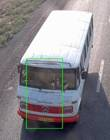
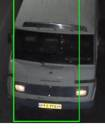
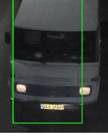
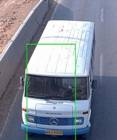
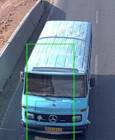
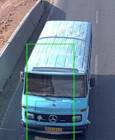
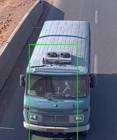
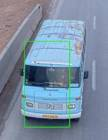
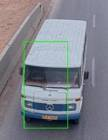
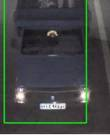
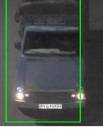
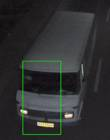
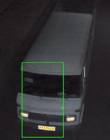
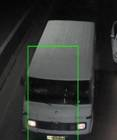
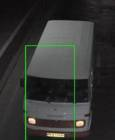
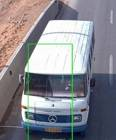
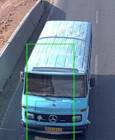
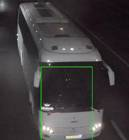
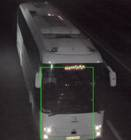
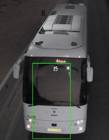
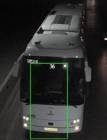
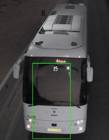
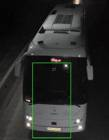
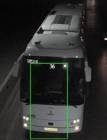
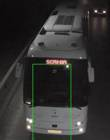
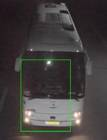
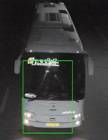
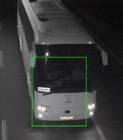
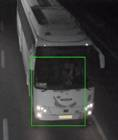
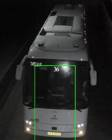
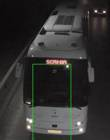
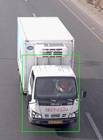
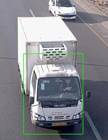
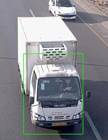
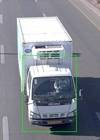
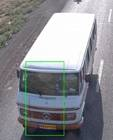
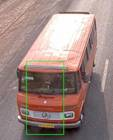
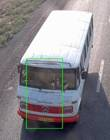
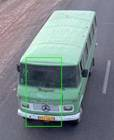
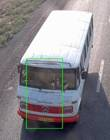
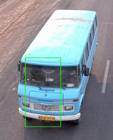
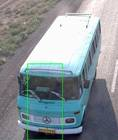
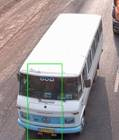
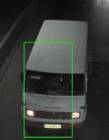
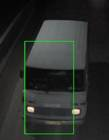
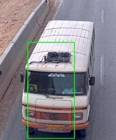
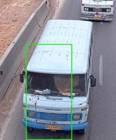
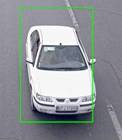
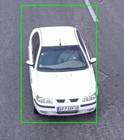
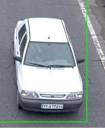
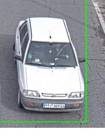
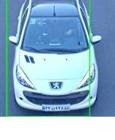
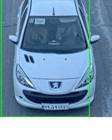
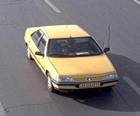
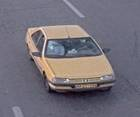
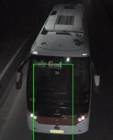
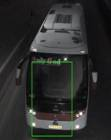
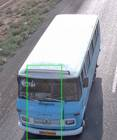
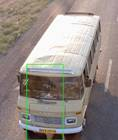
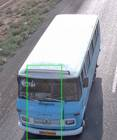
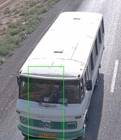
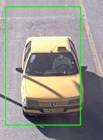
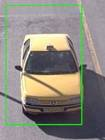
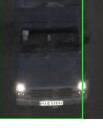
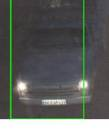
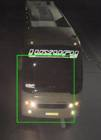
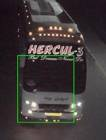
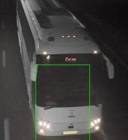
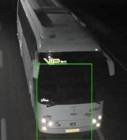
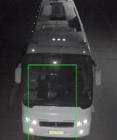
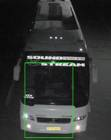
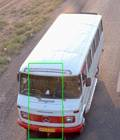
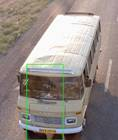
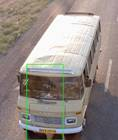
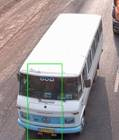
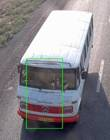
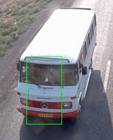
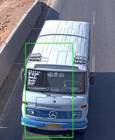
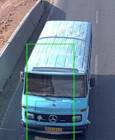
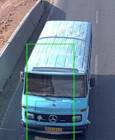
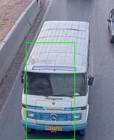
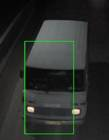
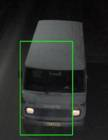
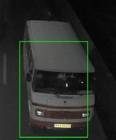
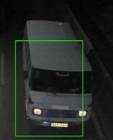
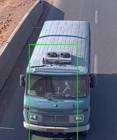
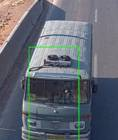
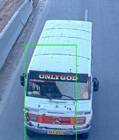
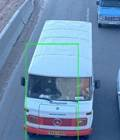
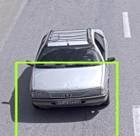
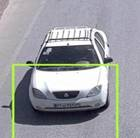
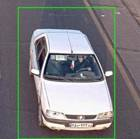
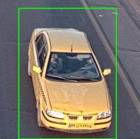
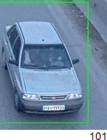
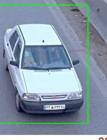
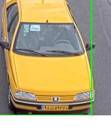
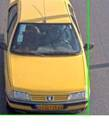
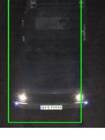
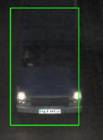
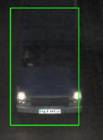
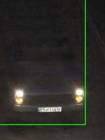
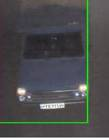
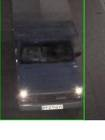
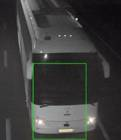
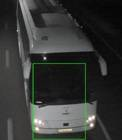
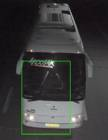
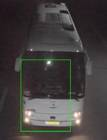
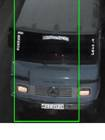
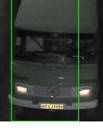
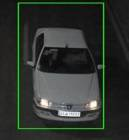
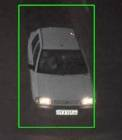
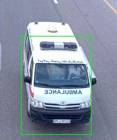
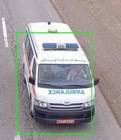
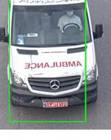
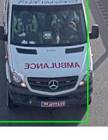
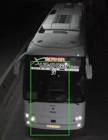
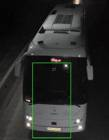
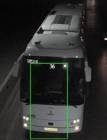
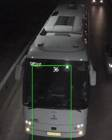
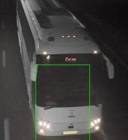
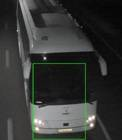
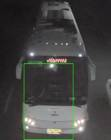
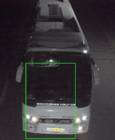
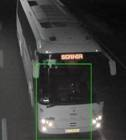
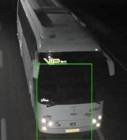
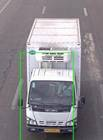
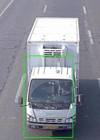
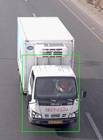
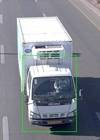
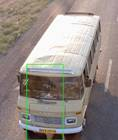
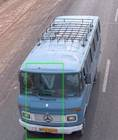
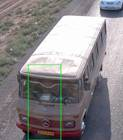
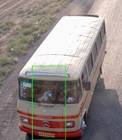
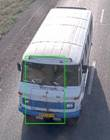
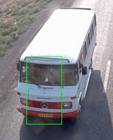
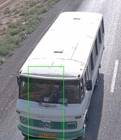
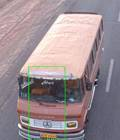
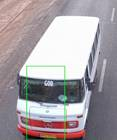
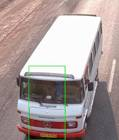
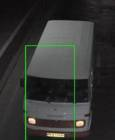
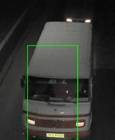
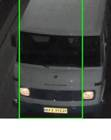
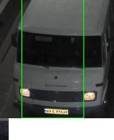
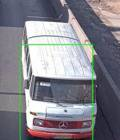
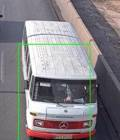
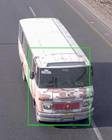
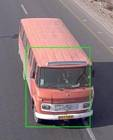
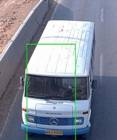
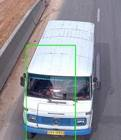
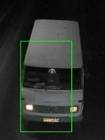
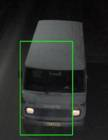
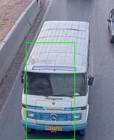
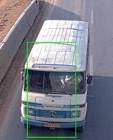
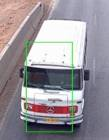
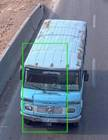
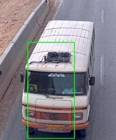
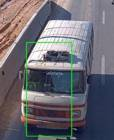
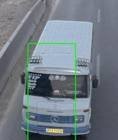
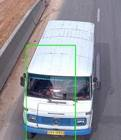
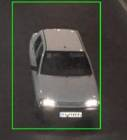
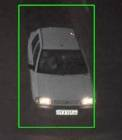
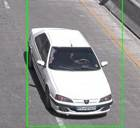
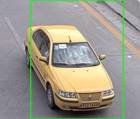
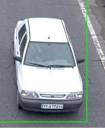
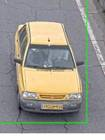
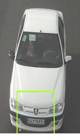
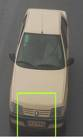
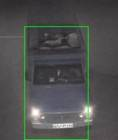
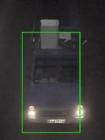
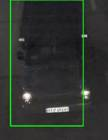
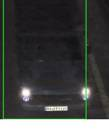
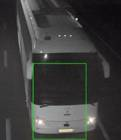
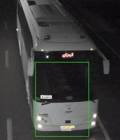
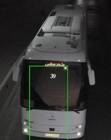
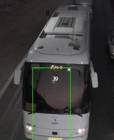
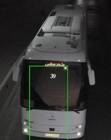
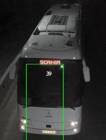
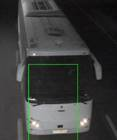
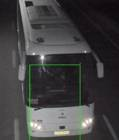
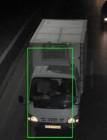
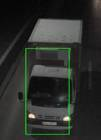
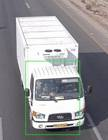
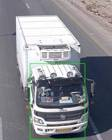
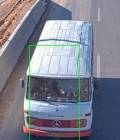
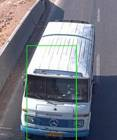
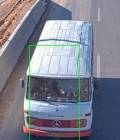
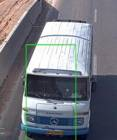
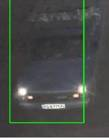
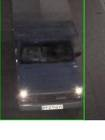
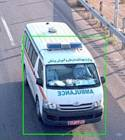
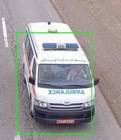
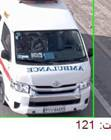
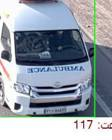
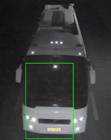
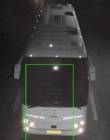
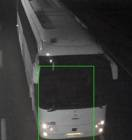
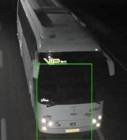
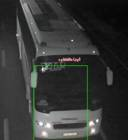
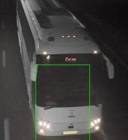
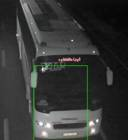
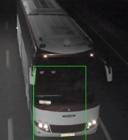
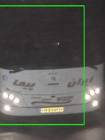
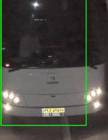
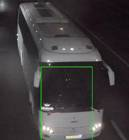
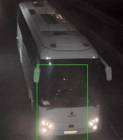
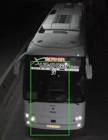
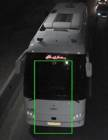
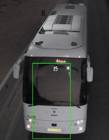
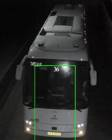
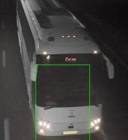
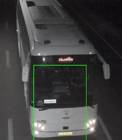
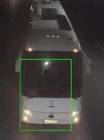
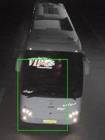
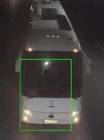
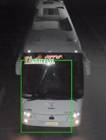
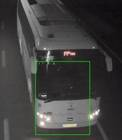
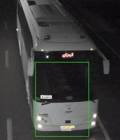
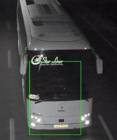
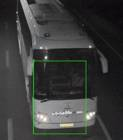
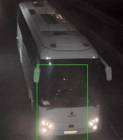
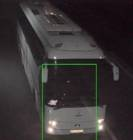
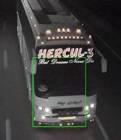
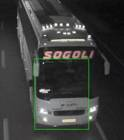
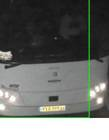
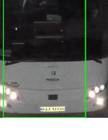
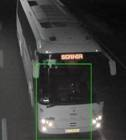
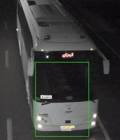
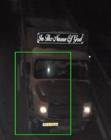
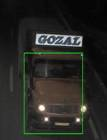
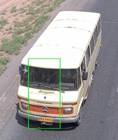
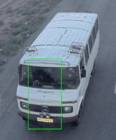
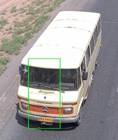
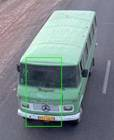
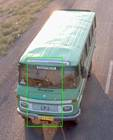
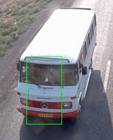
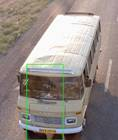
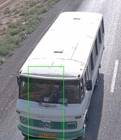
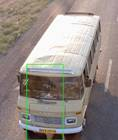
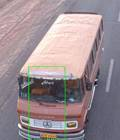
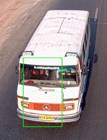
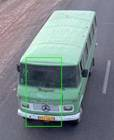
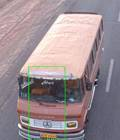
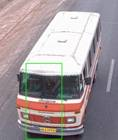
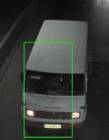
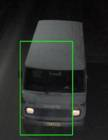
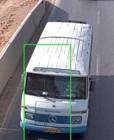
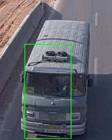
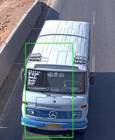
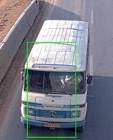
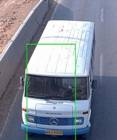
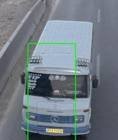
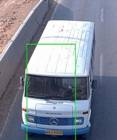
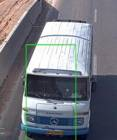
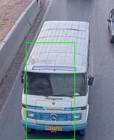
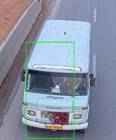
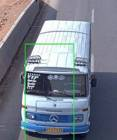
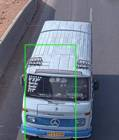
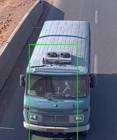
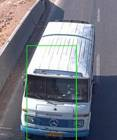
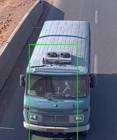
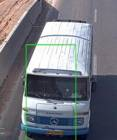
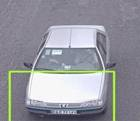
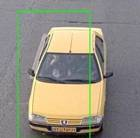
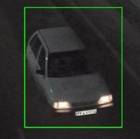
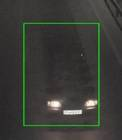
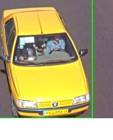
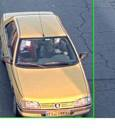
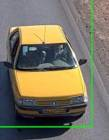
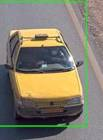
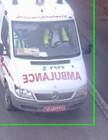
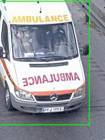
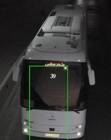
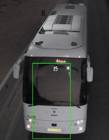
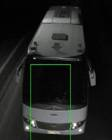
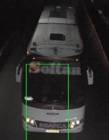
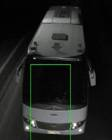
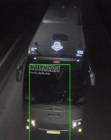
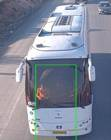
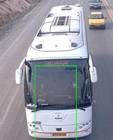
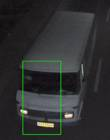
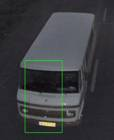
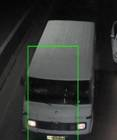
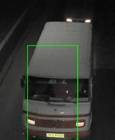
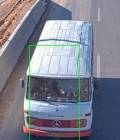
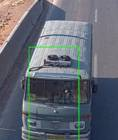
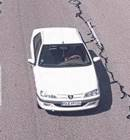
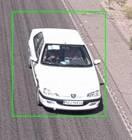
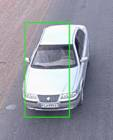
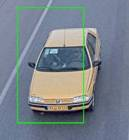
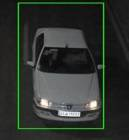
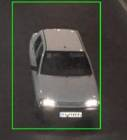
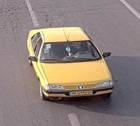
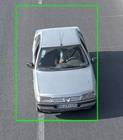
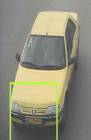
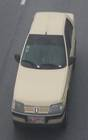
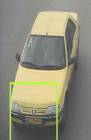
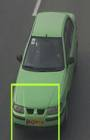
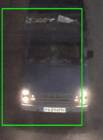
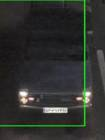
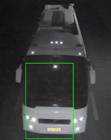
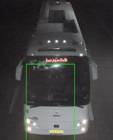
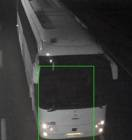
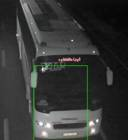
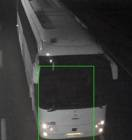
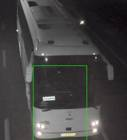
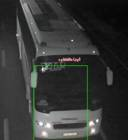
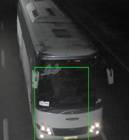
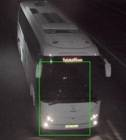
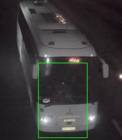
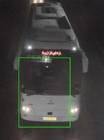
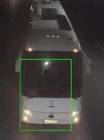
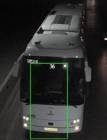
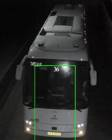
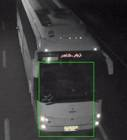
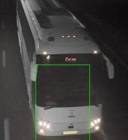
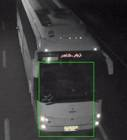
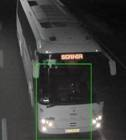
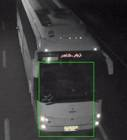
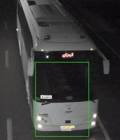
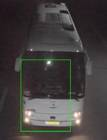
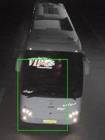
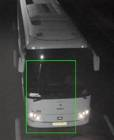
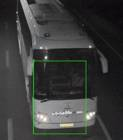
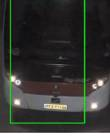
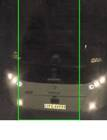
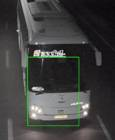
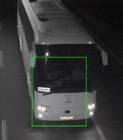
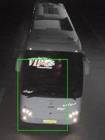
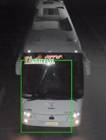
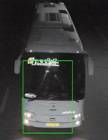
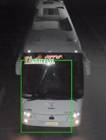
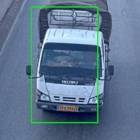
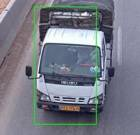
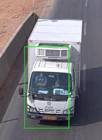
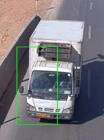
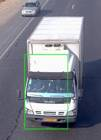
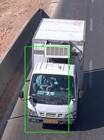
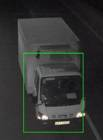
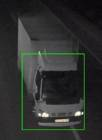
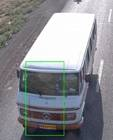
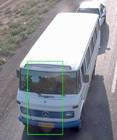
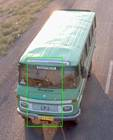
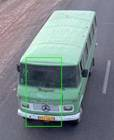
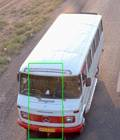
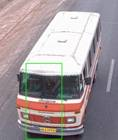
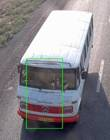
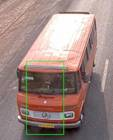
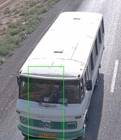
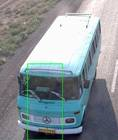
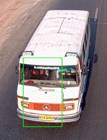
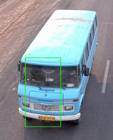
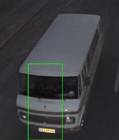
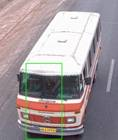
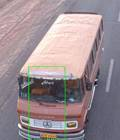
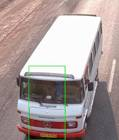
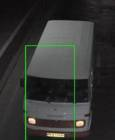
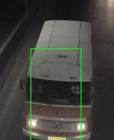
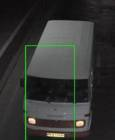
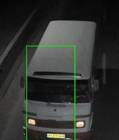
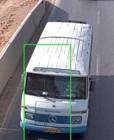
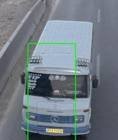
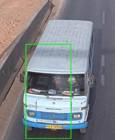
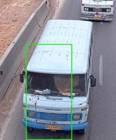
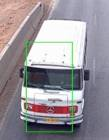
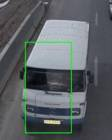
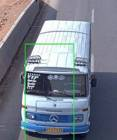
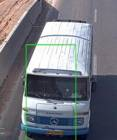
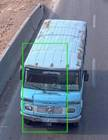
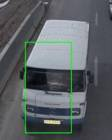
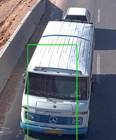
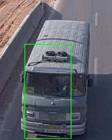
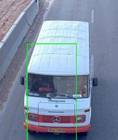
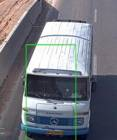
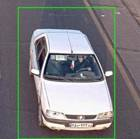
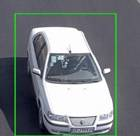
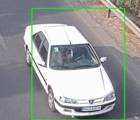
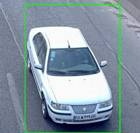
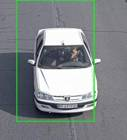
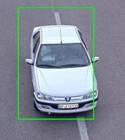
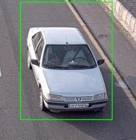
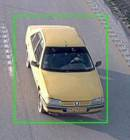
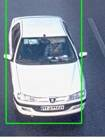
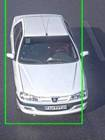
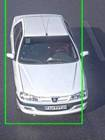
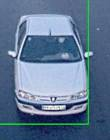
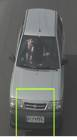
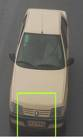
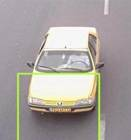
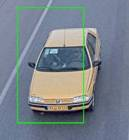
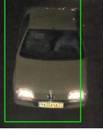
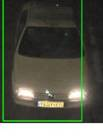
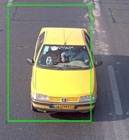
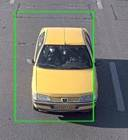
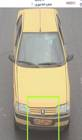
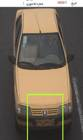
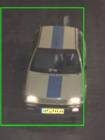
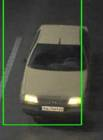
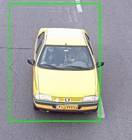
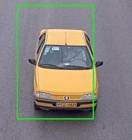
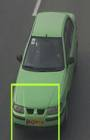
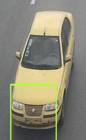
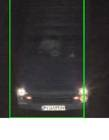
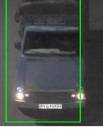
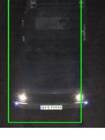
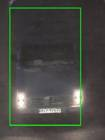
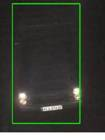
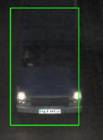
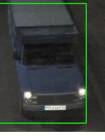
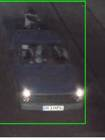
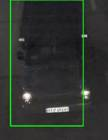
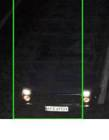
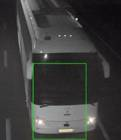
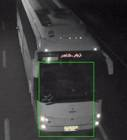
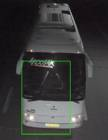
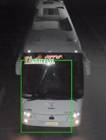
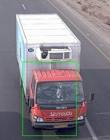
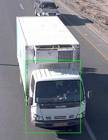
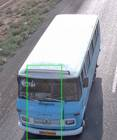
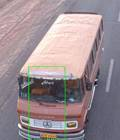
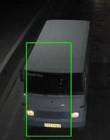
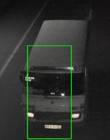
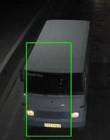
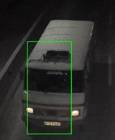
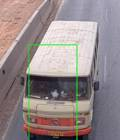
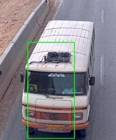
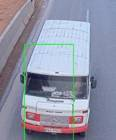
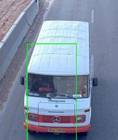
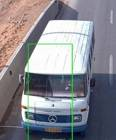
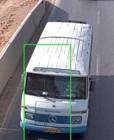
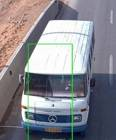
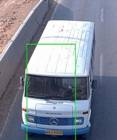
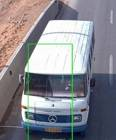
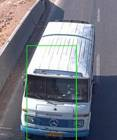
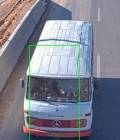
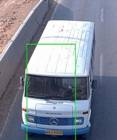
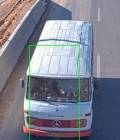
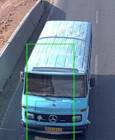
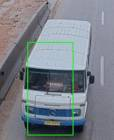
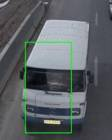
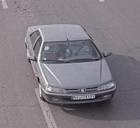
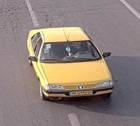
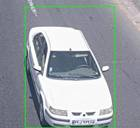
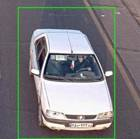
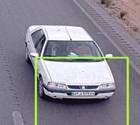
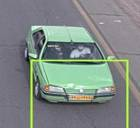
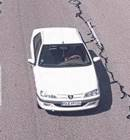
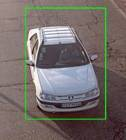
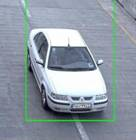
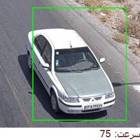
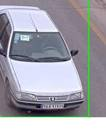
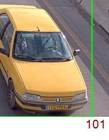
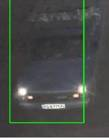
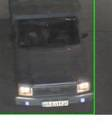
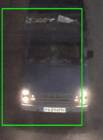
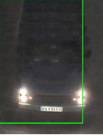
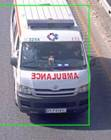
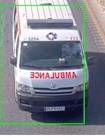
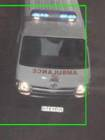
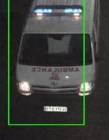
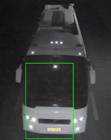
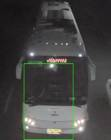
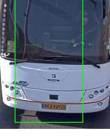
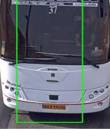
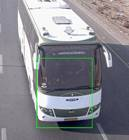
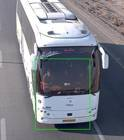
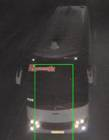
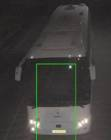
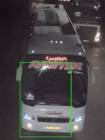
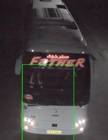
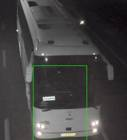
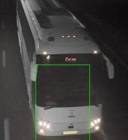
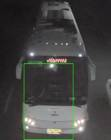
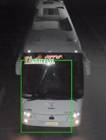
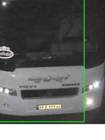
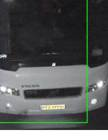
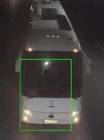
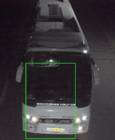
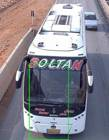
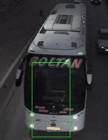
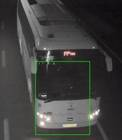
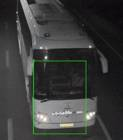
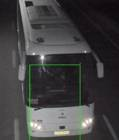
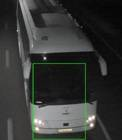
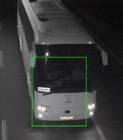
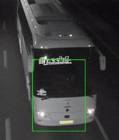
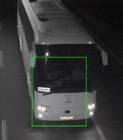
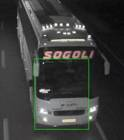
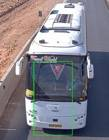
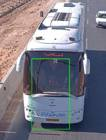
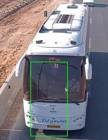
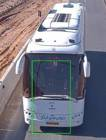
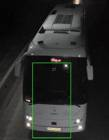
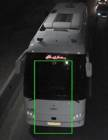
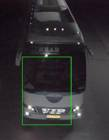
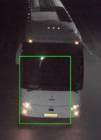
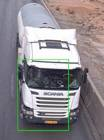
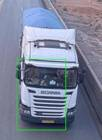
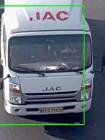
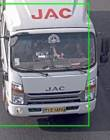
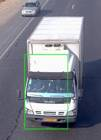
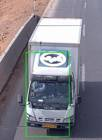
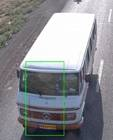
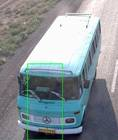
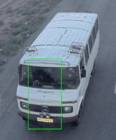
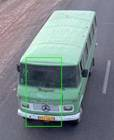
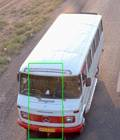
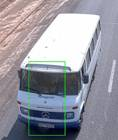
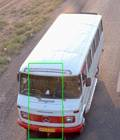
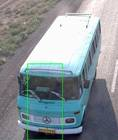
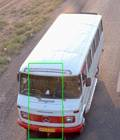
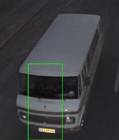
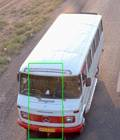
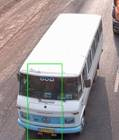
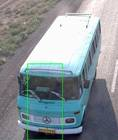
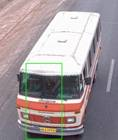
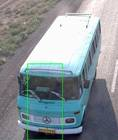
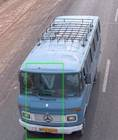
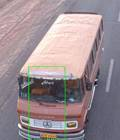
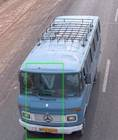
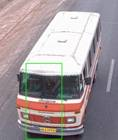
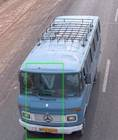
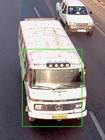
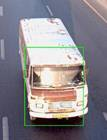
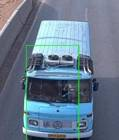
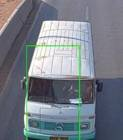
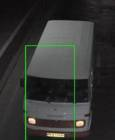
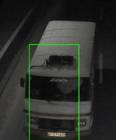
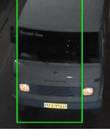
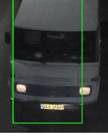
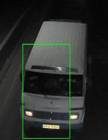
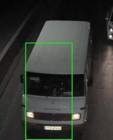
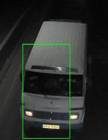
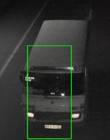
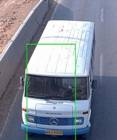
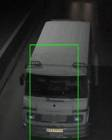
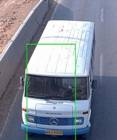
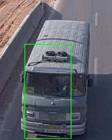
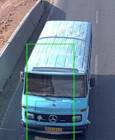
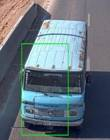
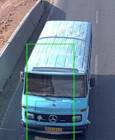
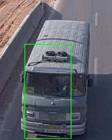
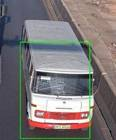
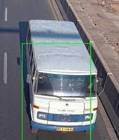
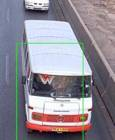
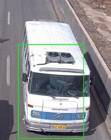
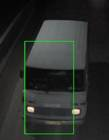
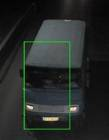
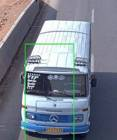
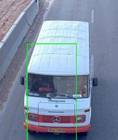
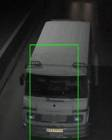
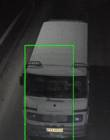
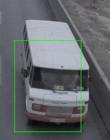
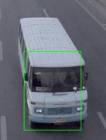
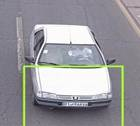
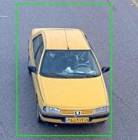
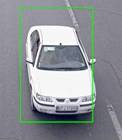
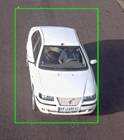
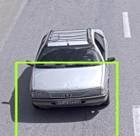
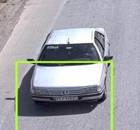
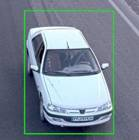
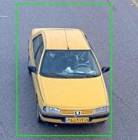
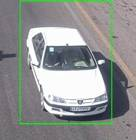
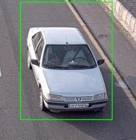
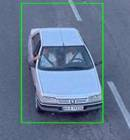
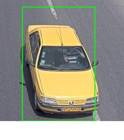
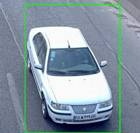
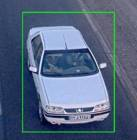
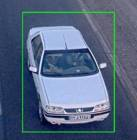
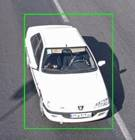
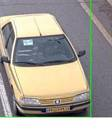
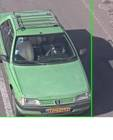
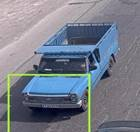
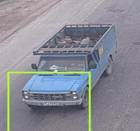
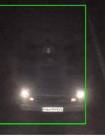
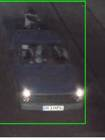
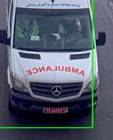
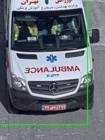
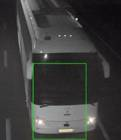
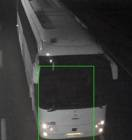
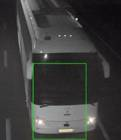
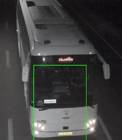
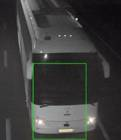
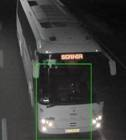
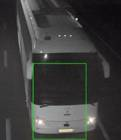
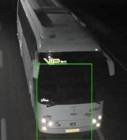
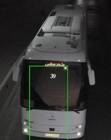
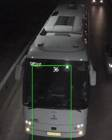
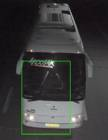
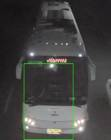
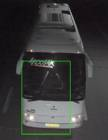
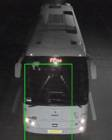
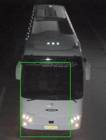
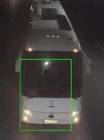
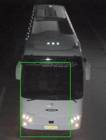
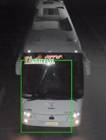
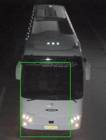
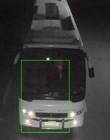
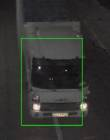
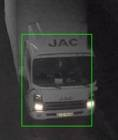
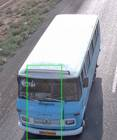
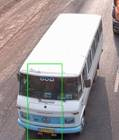
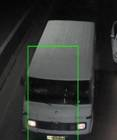
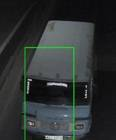
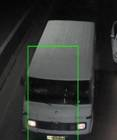
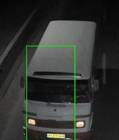
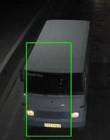
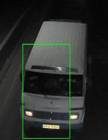
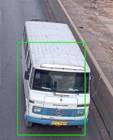
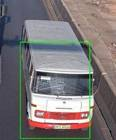
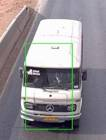
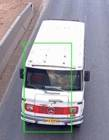
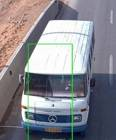
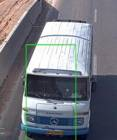
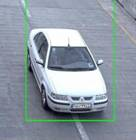
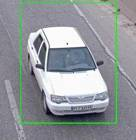
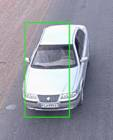
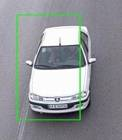
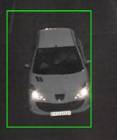
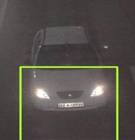
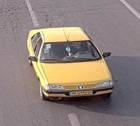
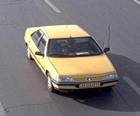
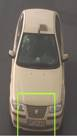
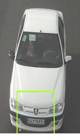
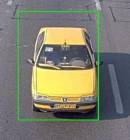
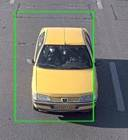
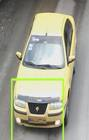
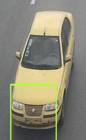
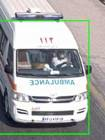
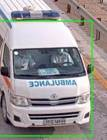
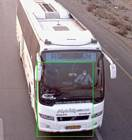
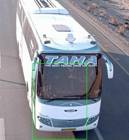
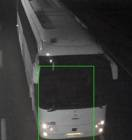
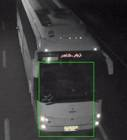
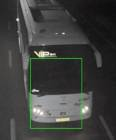
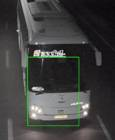
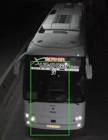
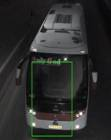
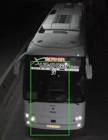
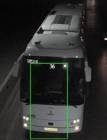
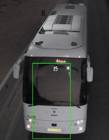
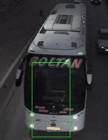
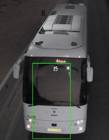
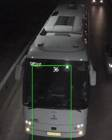
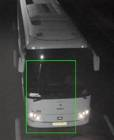
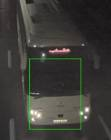
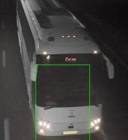
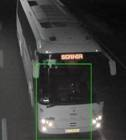
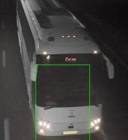
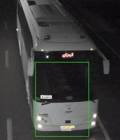
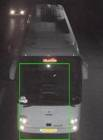
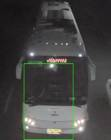
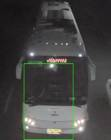
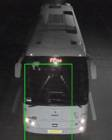
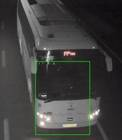
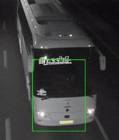
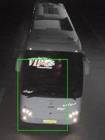
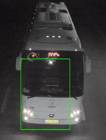
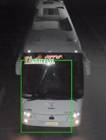
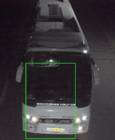
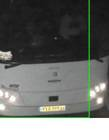
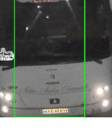
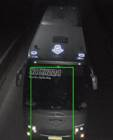
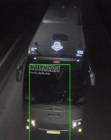
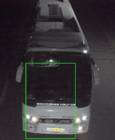
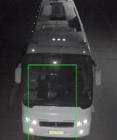
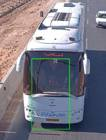
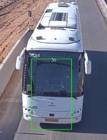
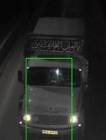
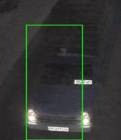
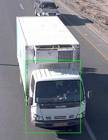
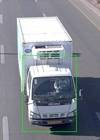
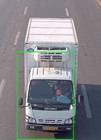
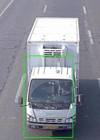
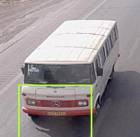
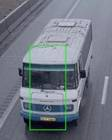
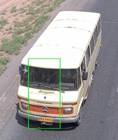
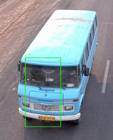
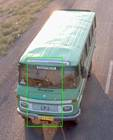
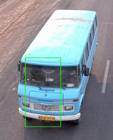
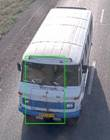
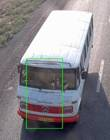
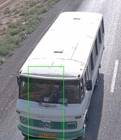
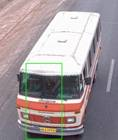
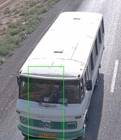
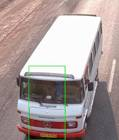
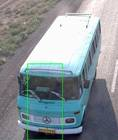
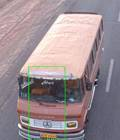
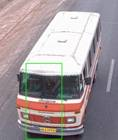
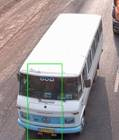
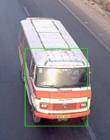
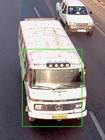
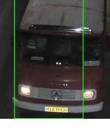
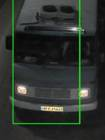
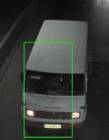
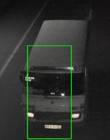
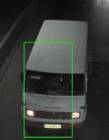
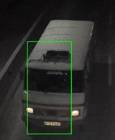
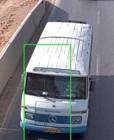
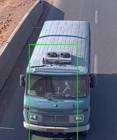
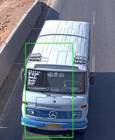
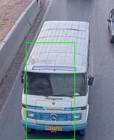
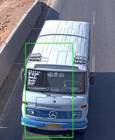
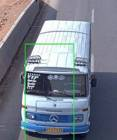
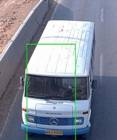
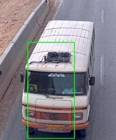
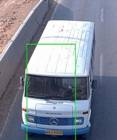
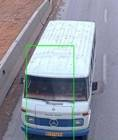
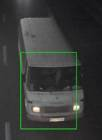
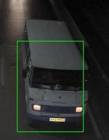
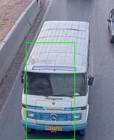
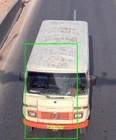
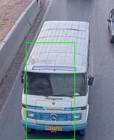
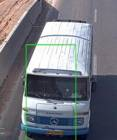
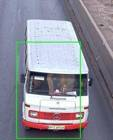
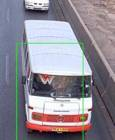
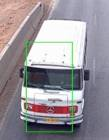
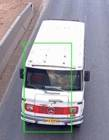
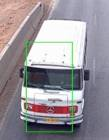
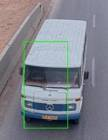
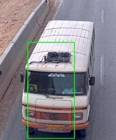
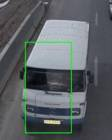
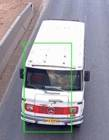
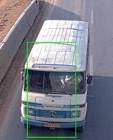
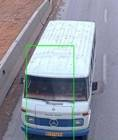
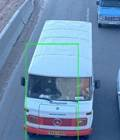
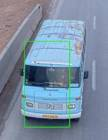
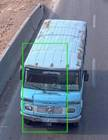
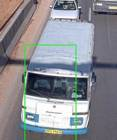
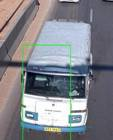
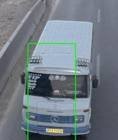
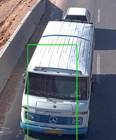
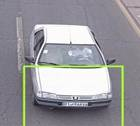
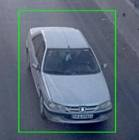
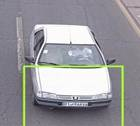
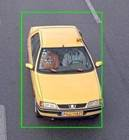
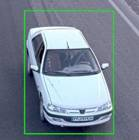
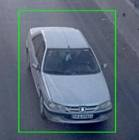
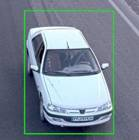
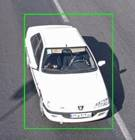
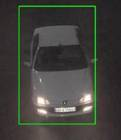
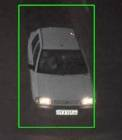
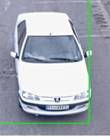
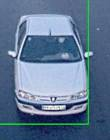
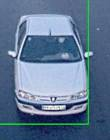
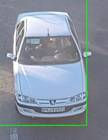
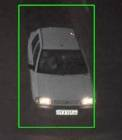
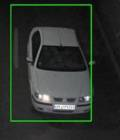
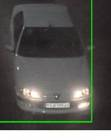
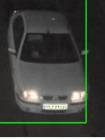
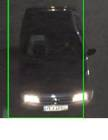
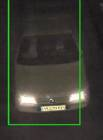
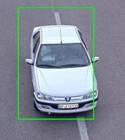
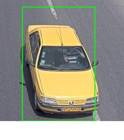
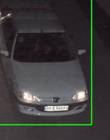
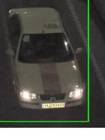
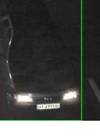
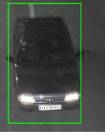
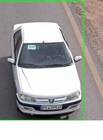
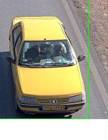
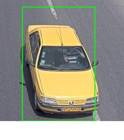
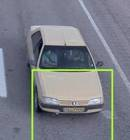
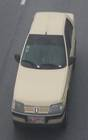
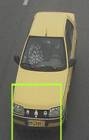
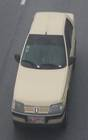
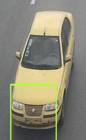
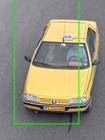
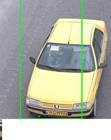
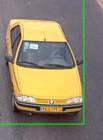
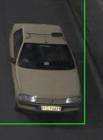
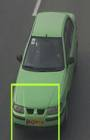
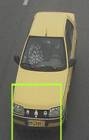
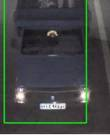
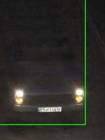
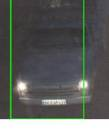
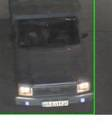
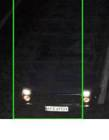
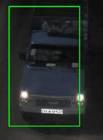
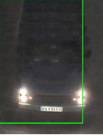
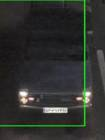
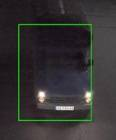
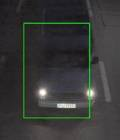
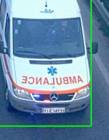
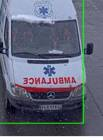
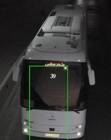
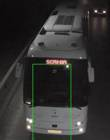
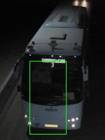
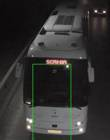
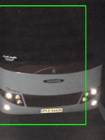
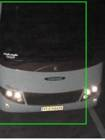
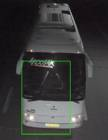
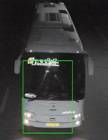
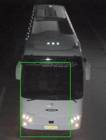
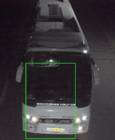
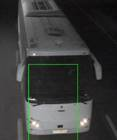
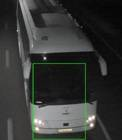
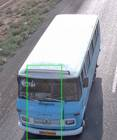
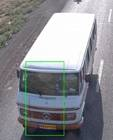
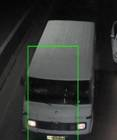
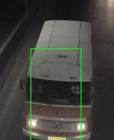
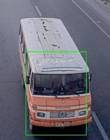
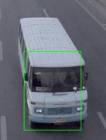
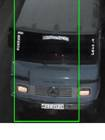
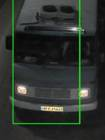
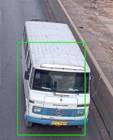
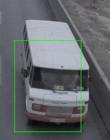
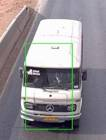
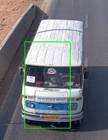
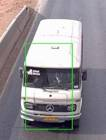
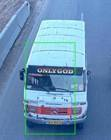
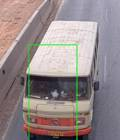
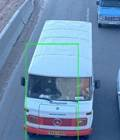
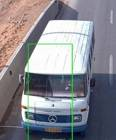
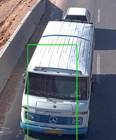
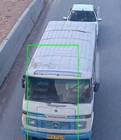
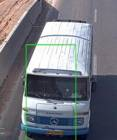
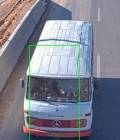
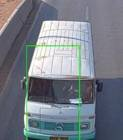
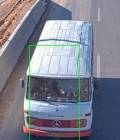
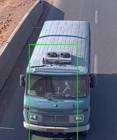
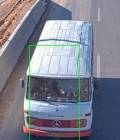
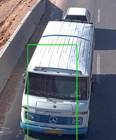
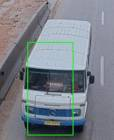
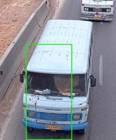
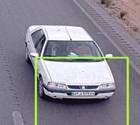
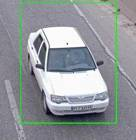
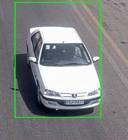
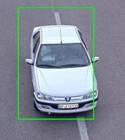
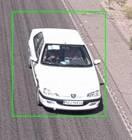
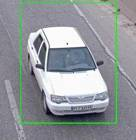
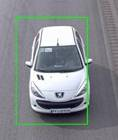
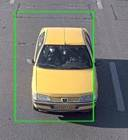
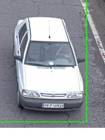
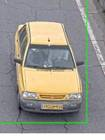
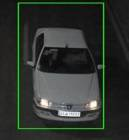
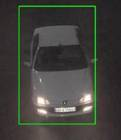
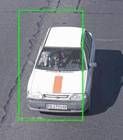
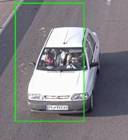
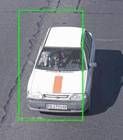
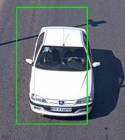
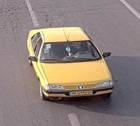
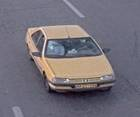
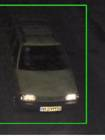
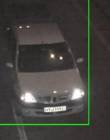
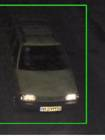
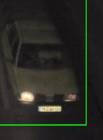
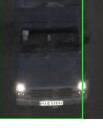
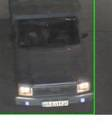
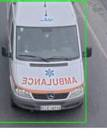
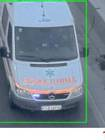
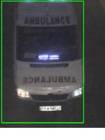
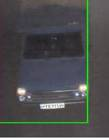
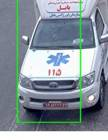
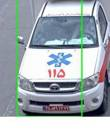
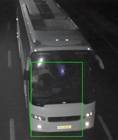
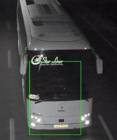
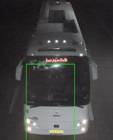
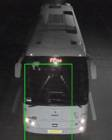
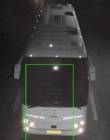
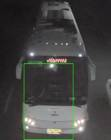
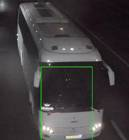
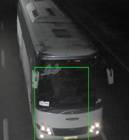
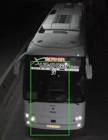
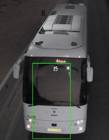
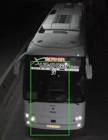
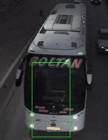
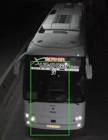
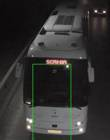
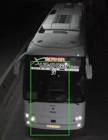
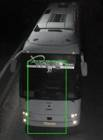
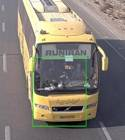
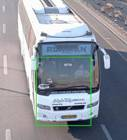
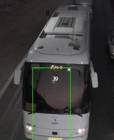
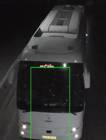
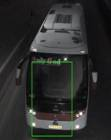
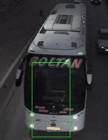
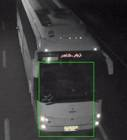
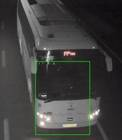
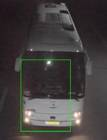
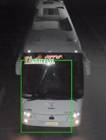
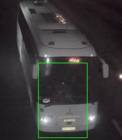
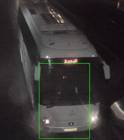
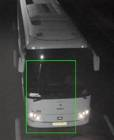
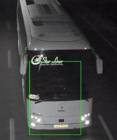
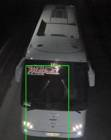
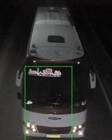
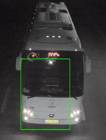
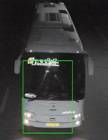
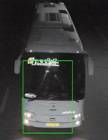
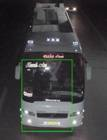
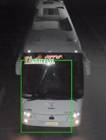
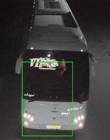
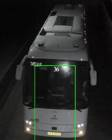
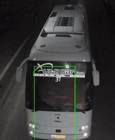
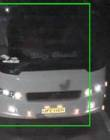
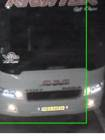
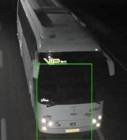
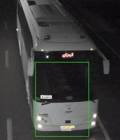
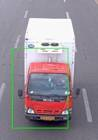
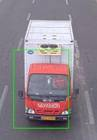
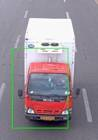
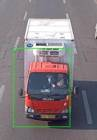
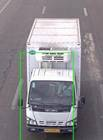
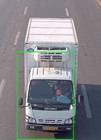
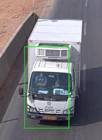
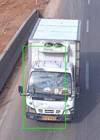
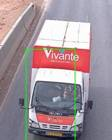
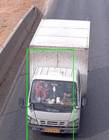
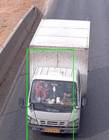
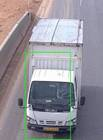
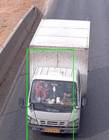
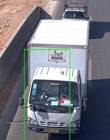
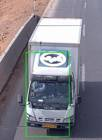
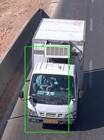
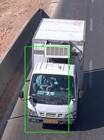
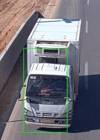
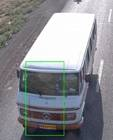
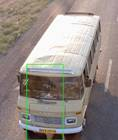
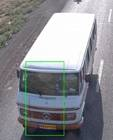
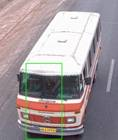
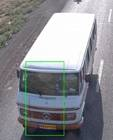
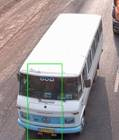
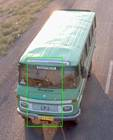
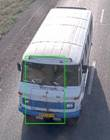
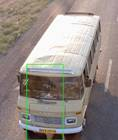
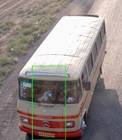
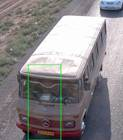
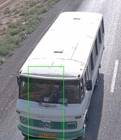
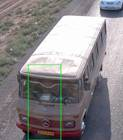
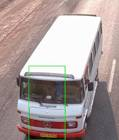
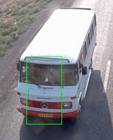
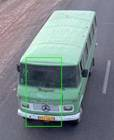
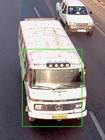
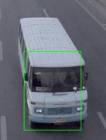
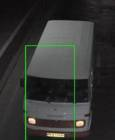
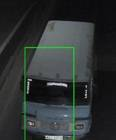
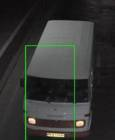
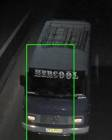
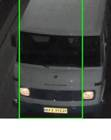
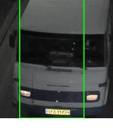
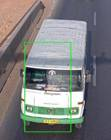
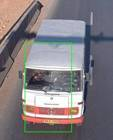
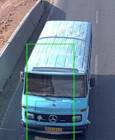
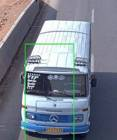
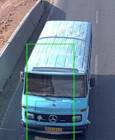
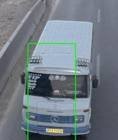
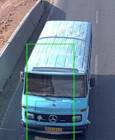
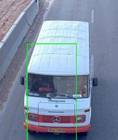
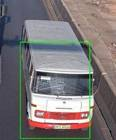
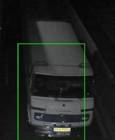
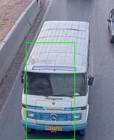
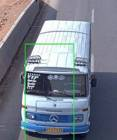
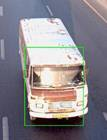
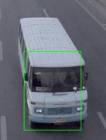
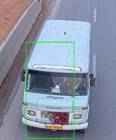
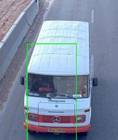
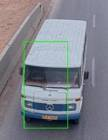
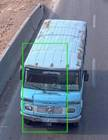
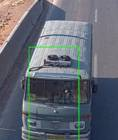
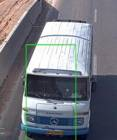
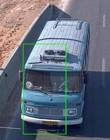
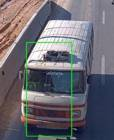
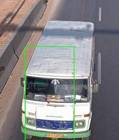
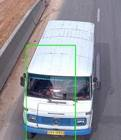
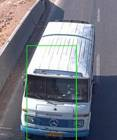
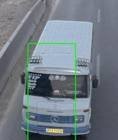
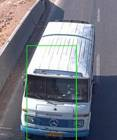
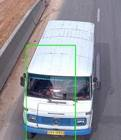
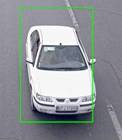
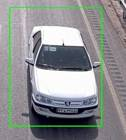
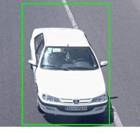
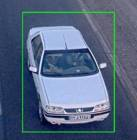
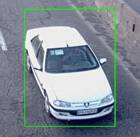
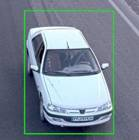
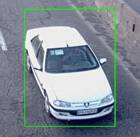
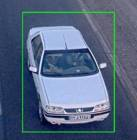
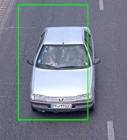
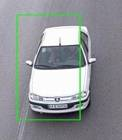
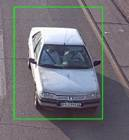
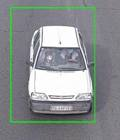
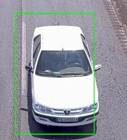
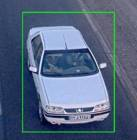
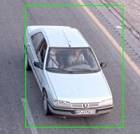
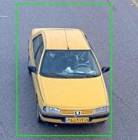
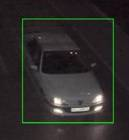
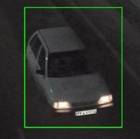
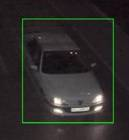
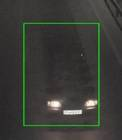
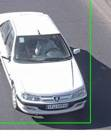
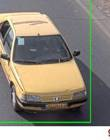
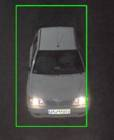
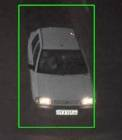
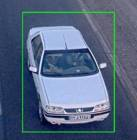
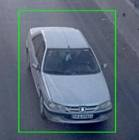
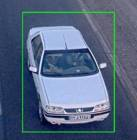
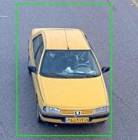
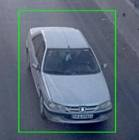
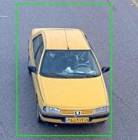
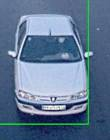
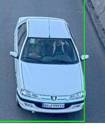
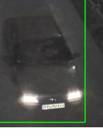
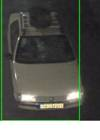
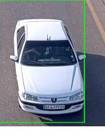
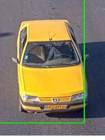
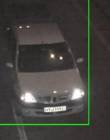
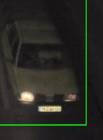
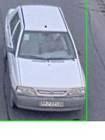
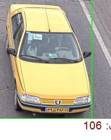
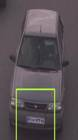
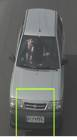
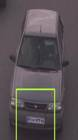
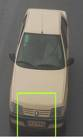
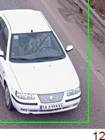
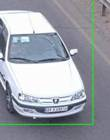
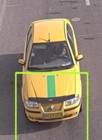
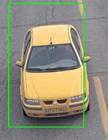
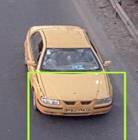
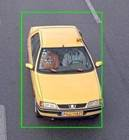
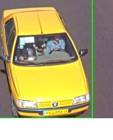
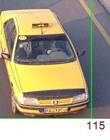
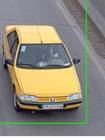
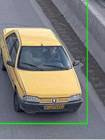
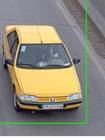
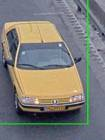
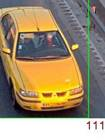
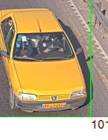
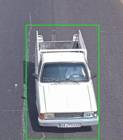
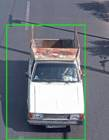
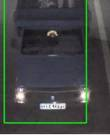
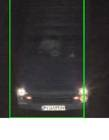
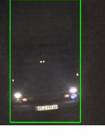
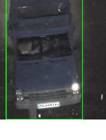
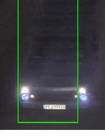
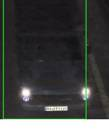
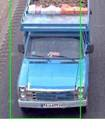
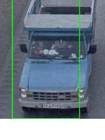
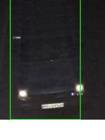
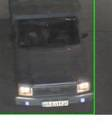
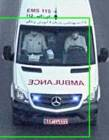
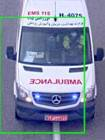
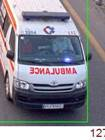
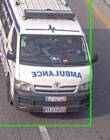
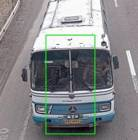
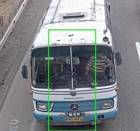
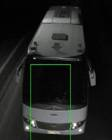
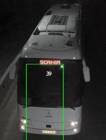
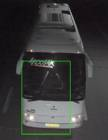
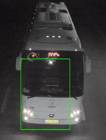
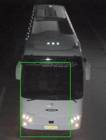
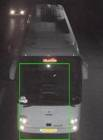
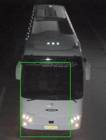
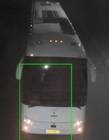
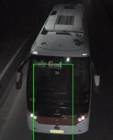
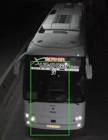
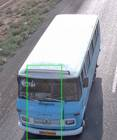
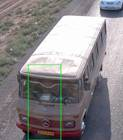
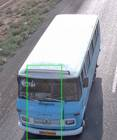
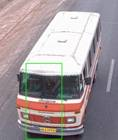
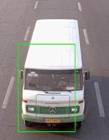
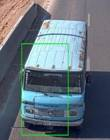
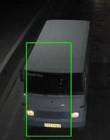
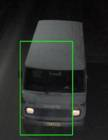
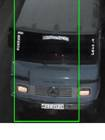
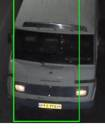
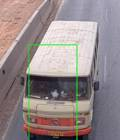
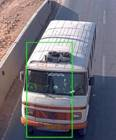
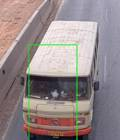
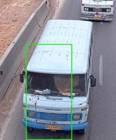
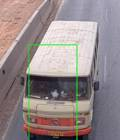
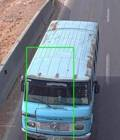
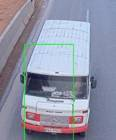
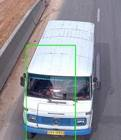
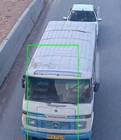
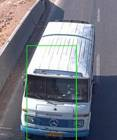
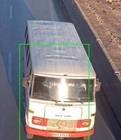
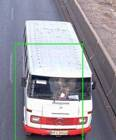
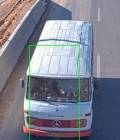
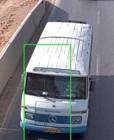
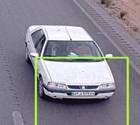
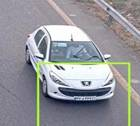
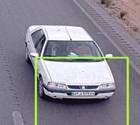
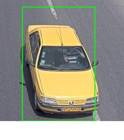
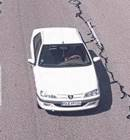
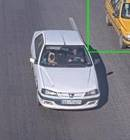
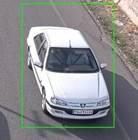
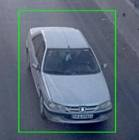
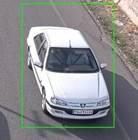
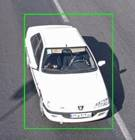
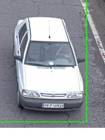
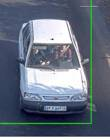
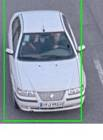
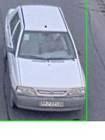
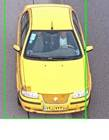
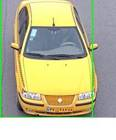
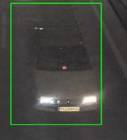
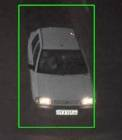
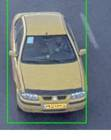
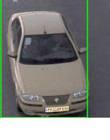
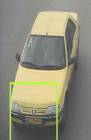
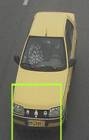
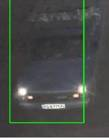
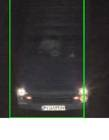
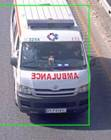
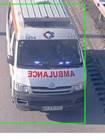
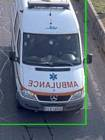
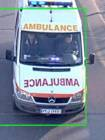
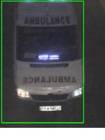
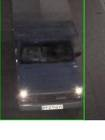
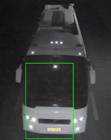
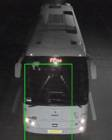
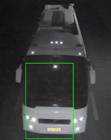
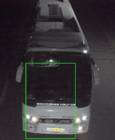
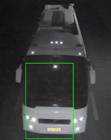
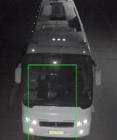
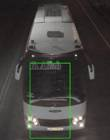
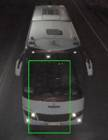
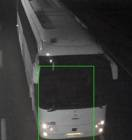
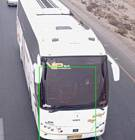
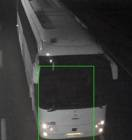
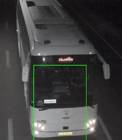
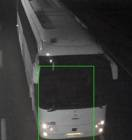
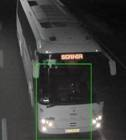
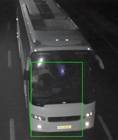
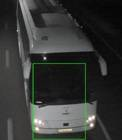
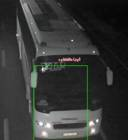
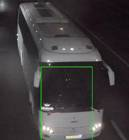
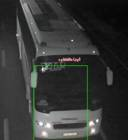
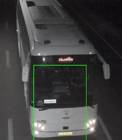
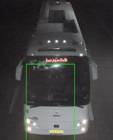
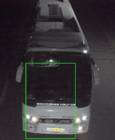
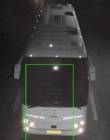
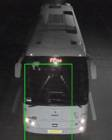
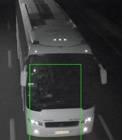
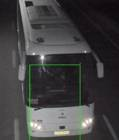
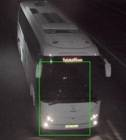
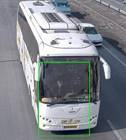
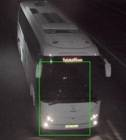
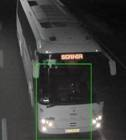
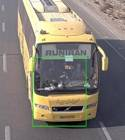
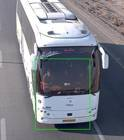
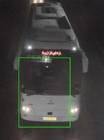
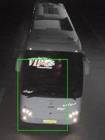
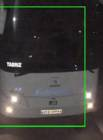
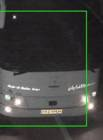
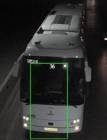
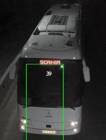
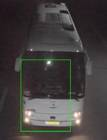
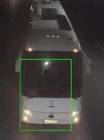
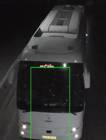
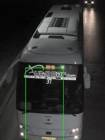
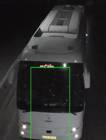
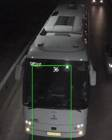
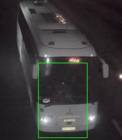
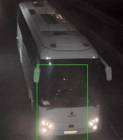
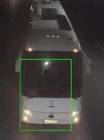
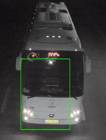
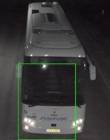
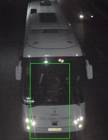
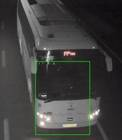
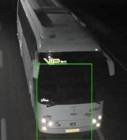
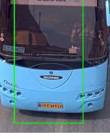
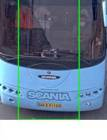
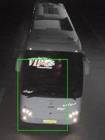
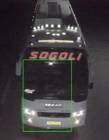
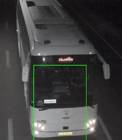
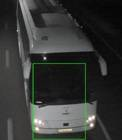
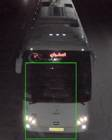
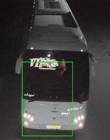
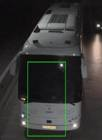
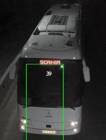
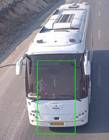
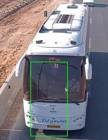
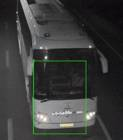
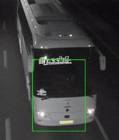
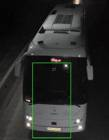
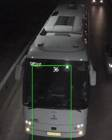
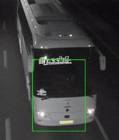
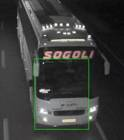
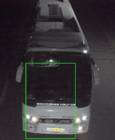
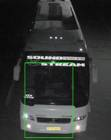
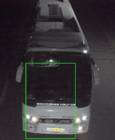
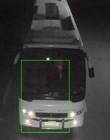
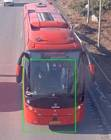
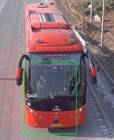
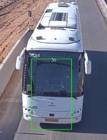
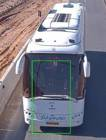
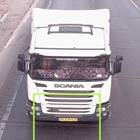
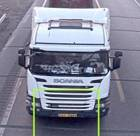
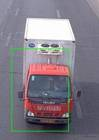
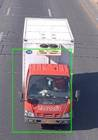
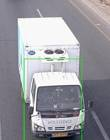
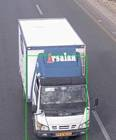
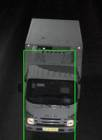
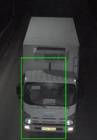
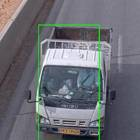
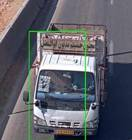
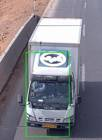
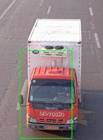
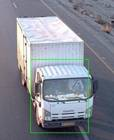
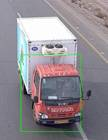
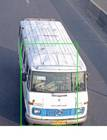
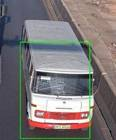
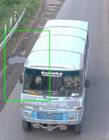
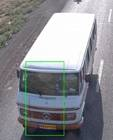
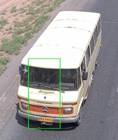
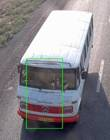
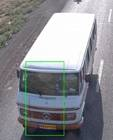
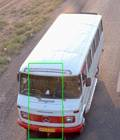
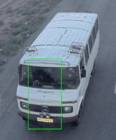
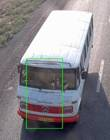
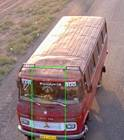
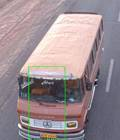
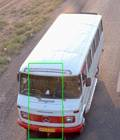
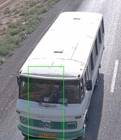
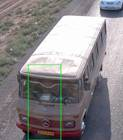
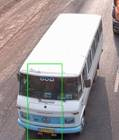
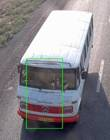
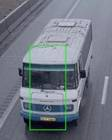
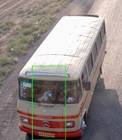
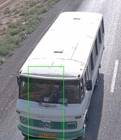
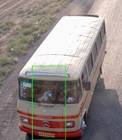
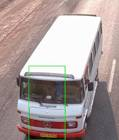
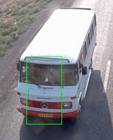
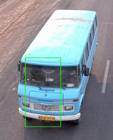
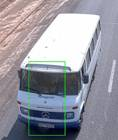
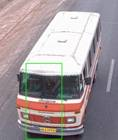
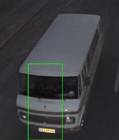
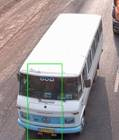
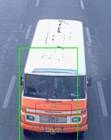
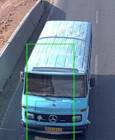
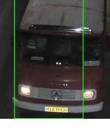
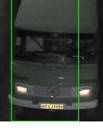
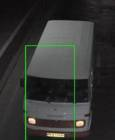
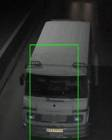
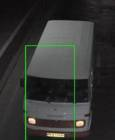
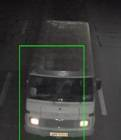
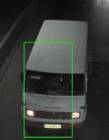
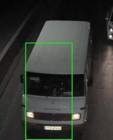
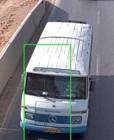
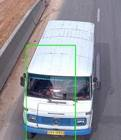
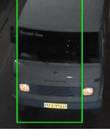
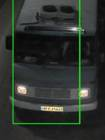
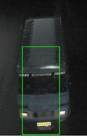
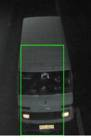
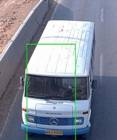
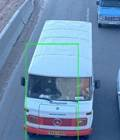
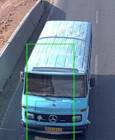
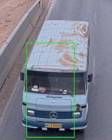
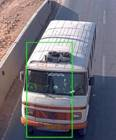
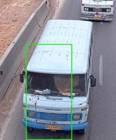
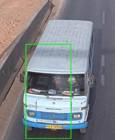
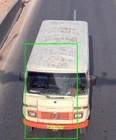
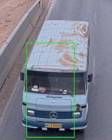
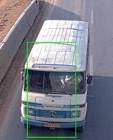
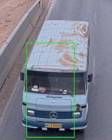
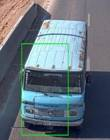
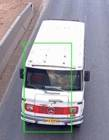
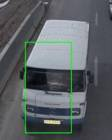
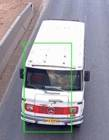
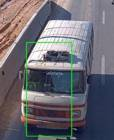
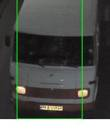
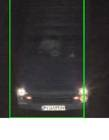
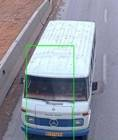
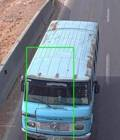
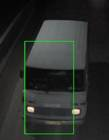
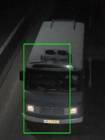
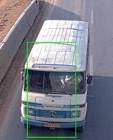
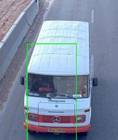
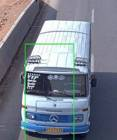
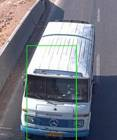
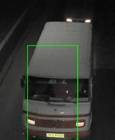
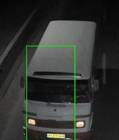
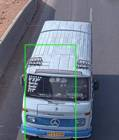
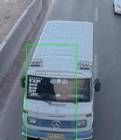
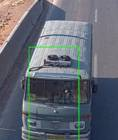
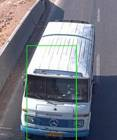
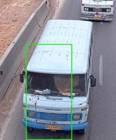
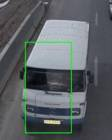
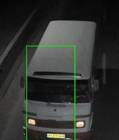
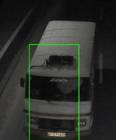
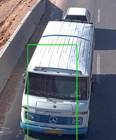
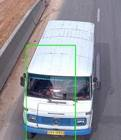
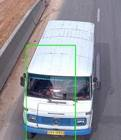
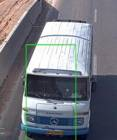
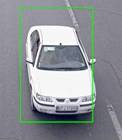
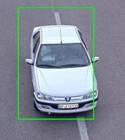
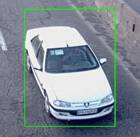
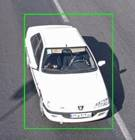
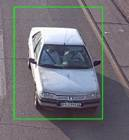
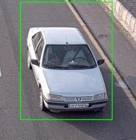
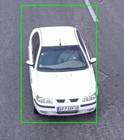
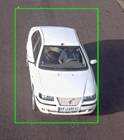
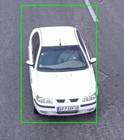
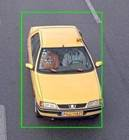
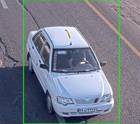
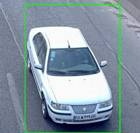
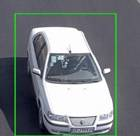
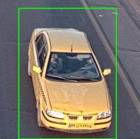
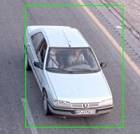
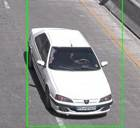
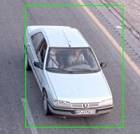
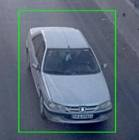
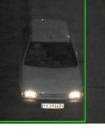
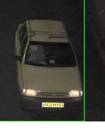
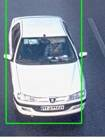
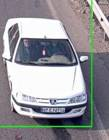
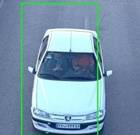
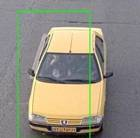
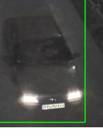
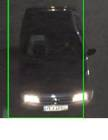
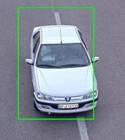
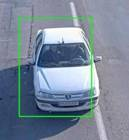
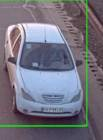
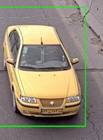
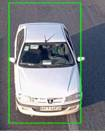
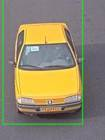
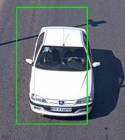
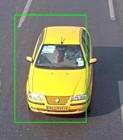
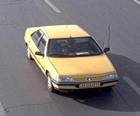
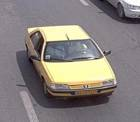
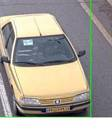
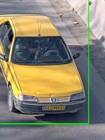
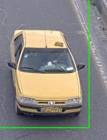
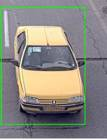
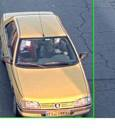
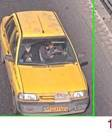
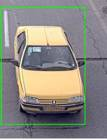
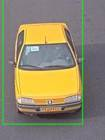
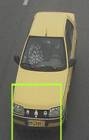
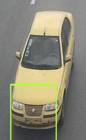
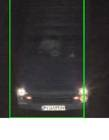
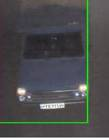
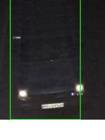
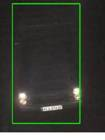
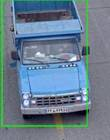
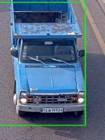
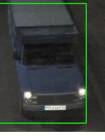
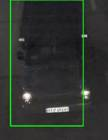
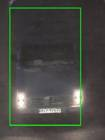
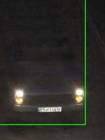
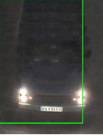
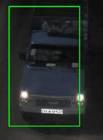

In [6]:
from IPython.display import HTML, display
from vehicle_classifier import duplicate_detection as dd

THRESHOLD = 0.75

hashed = dd.compute_phashes(dataset_dir='../dataset/Combined Dataset',hash_method = "phash" )
report = dd.build_duplicate_report(hashed, similarity_threshold=THRESHOLD)

print('='*20)
print('--- all similar pairs ---')
display(HTML(dd.table_to_html(report)))

# dd.save_duplicate_report(report)
# dd.save_label_corrections(report)

# dd.compare_images(
#     r"dataset\raw\train\autobus\216664450.jpg",
#     r"dataset\raw\train\autobus\216802875.jpg",
#     hash_method="phash",   # "ahash" | "phash" | "dhash" | "whash"
# )

# final quick stats of the Combined Dataset

In [7]:
from pathlib import Path

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


test:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 49 images
  autobus: 49 images
  kamyun: 36 images
  kamyunet: 64 images
  minibus: 46 images
  savari: 51 images
  taxi: 50 images
  vanet: 50 images
Total images: 395

train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 348 images
  autobus: 463 images
  kamyun: 335 images
  kamyunet: 594 images
  minibus: 398 images
  savari: 502 images
  taxi: 480 images
  vanet: 746 images
Total images: 3866


In [8]:
from pathlib import Path

import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Locate the raw dataset
# ---------------------------------------------------------

data_root = Path("..") / "dataset" / "Combined Dataset"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}


# ---------------------------------------------------------
# 2. Inspect every image in every class of every split
# ---------------------------------------------------------

records = []

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):

        for file_path in sorted(class_dir.rglob("*")):

            # Ignore files that are not recognized as images
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in image_extensions:
                continue

            # Default values in case the image cannot be read
            width = None
            height = None
            dpi_x = None
            dpi_y = None
            image_format = None
            mode = None
            readable = False
            aspect_ratio = None
            error = None

            try:
                # Open the image
                with Image.open(file_path) as img:

                    # Basic image information
                    width, height = img.size
                    image_format = img.format
                    mode = img.mode

                    # DPI information
                    dpi = img.info.get("dpi")

                    if dpi is not None:
                        dpi_x, dpi_y = dpi

                    # Aspect ratio
                    if height != 0:
                        aspect_ratio = width / height

                    # Verify that the image data can actually be read
                    img.verify()

                    readable = True

            except Exception as e:
                error = str(e)

            # Store everything in one record
            records.append({
                "split": split_dir.name,
                "class": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path),
                "width": width,
                "height": height,
                "dpi_x": dpi_x,
                "dpi_y": dpi_y,
                "format": image_format,
                "mode": mode,
                "readable": readable,
                "aspect_ratio": aspect_ratio,
                "error": error,
            })


# ---------------------------------------------------------
# 3. Create one master DataFrame
# ---------------------------------------------------------

image_metadata = pd.DataFrame(records)


# ---------------------------------------------------------
# 4. Display basic information
# ---------------------------------------------------------

print(f"Total images inspected: {len(image_metadata)}")

print(
    f"Unreadable images: "
    f"{(~image_metadata['readable']).sum()}"
)

Total images inspected: 4261
Unreadable images: 0
